In [1]:
import tensorflow as tf
tf.__version__

'2.9.0'

In [2]:
import os

# Walk through the file and list the number of files
for dirpath, dirnames, filenames in os.walk("images"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

There are 2 directories and 0 images in 'images'
There are 7 directories and 0 images in 'images/test'
There are 0 directories and 1774 images in 'images/test/happy'
There are 0 directories and 1247 images in 'images/test/sad'
There are 0 directories and 1024 images in 'images/test/fear'
There are 0 directories and 831 images in 'images/test/surprise'
There are 0 directories and 1233 images in 'images/test/neutral'
There are 0 directories and 958 images in 'images/test/angry'
There are 0 directories and 111 images in 'images/test/disgust'
There are 7 directories and 0 images in 'images/train'
There are 0 directories and 7215 images in 'images/train/happy'
There are 0 directories and 4830 images in 'images/train/sad'
There are 0 directories and 4097 images in 'images/train/fear'
There are 0 directories and 3171 images in 'images/train/surprise'
There are 0 directories and 4965 images in 'images/train/neutral'
There are 0 directories and 3995 images in 'images/train/angry'
There are 0 di

['PrivateTest_62257937.jpg']


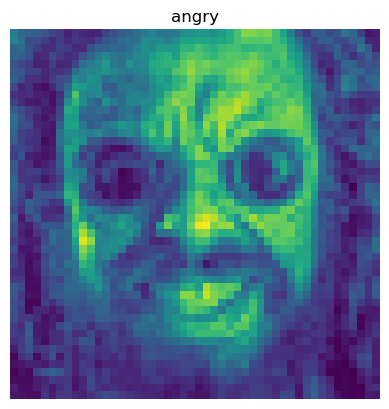

Image shape (48, 48)
['PublicTest_65689063.jpg']


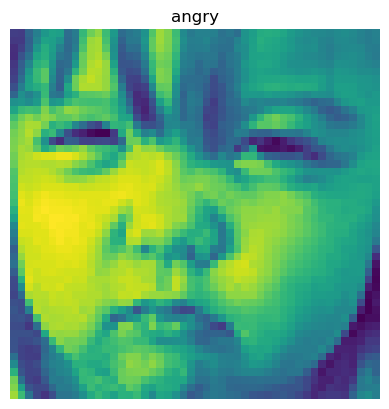

Image shape (48, 48)
['PublicTest_9227570.jpg']


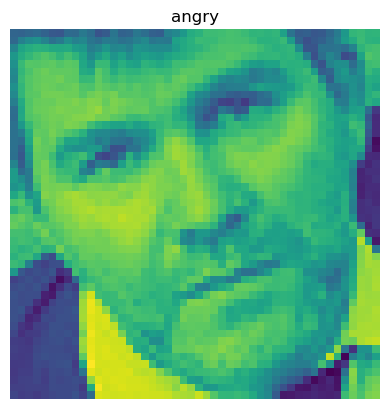

Image shape (48, 48)
['PublicTest_44184063.jpg']


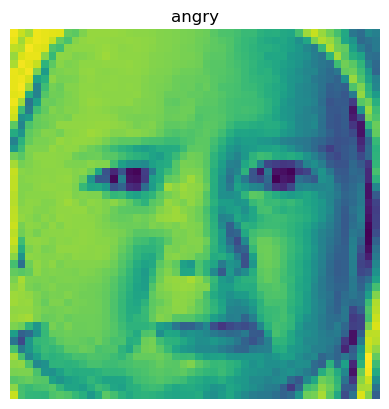

Image shape (48, 48)
['PrivateTest_83094105.jpg']


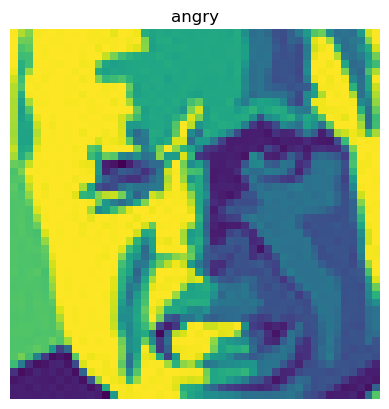

Image shape (48, 48)
['PublicTest_48036150.jpg']


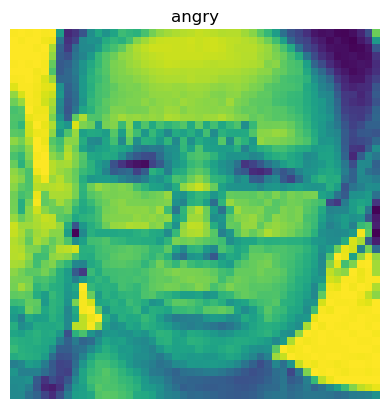

Image shape (48, 48)
['PublicTest_85454471.jpg']


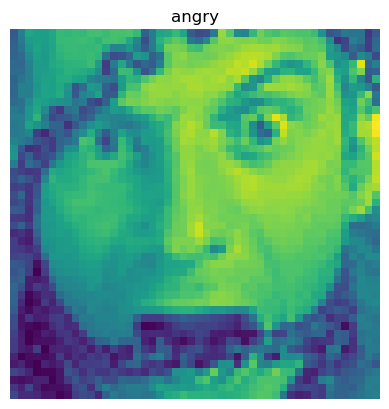

Image shape (48, 48)
['PublicTest_66091352.jpg']


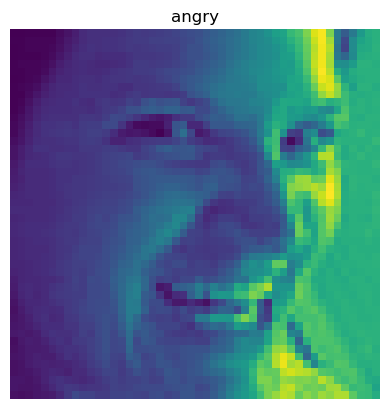

Image shape (48, 48)
['PrivateTest_66535975.jpg']


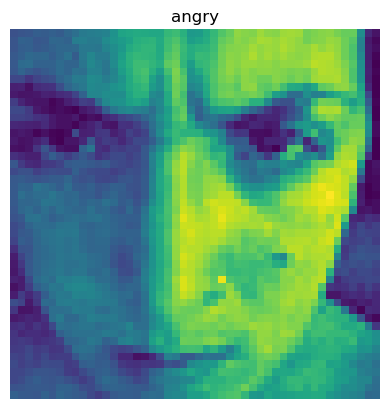

Image shape (48, 48)
['PrivateTest_46420872.jpg']


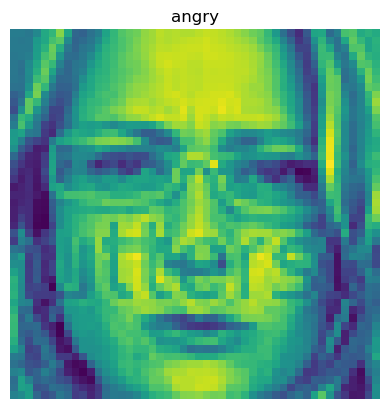

Image shape (48, 48)


In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir,target_class):
  # Setup target directory
  target_folder = target_dir+target_class

  #Get random image path
  random_image = random.sample(os.listdir(target_folder),1)
  print(random_image)

  #Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder+"/"+random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")
  plt.show()

  print(f"Image shape {img.shape}") # Shows the shape of the image

  return img


for i in range(10):
  img = view_random_image(target_dir="images/test/",
                        target_class="angry")

In [4]:
img = tf.cast(tf.constant(img),dtype=tf.float32)
img

Metal device set to: Apple M1

systemMemory: 8.00 GB
maxCacheSize: 2.67 GB



2023-05-29 11:47:07.847859: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-05-29 11:47:07.848441: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


<tf.Tensor: shape=(48, 48), dtype=float32, numpy=
array([[ 86.,  86.,  82., ..., 125., 131., 125.],
       [ 84.,  82.,  84., ..., 136., 119., 130.],
       [ 83.,  84.,  83., ..., 149., 119., 129.],
       ...,
       [ 74., 117.,  90., ...,   9.,  47.,  93.],
       [ 77., 117., 112., ...,  13.,  35., 101.],
       [ 90.,  98., 114., ...,  15.,  45., 100.]], dtype=float32)>

In [5]:
img.shape

TensorShape([48, 48])

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_dir="images/train/"
test_dir="images/test/"

train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               target_size=(48,48),
                                               class_mode="categorical",
                                               seed=42)
test_data = test_datagen.flow_from_directory(test_dir,
                                             batch_size=32,
                                             target_size=(48,48),
                                             class_mode="categorical",
                                             seed=42)


# 1. Create a base model with tf.keras.applciations
base_model = tf.keras.applications.vgg19.VGG19(include_top=False) # include_top -> last layer (will be different for different datasets)

# 2. Freeze the base model, underlying pre-trained weights arent updated during training
base_model.trainable=False

# 3. Create inputs into our model
inputs = tf.keras.layers.Input(shape=(48,48,3),
                               name="input_layer")

# 4. (Optional) -> if using resnet -> need to normalize inputs -> not needed for EfficientNet
# x = tf.keras.layers.experimental.preprocessing.Rescaling(1./255)(inputs)

# 5. Pass the inputs to base_model
x = base_model(inputs)

print("shape after passing inputs through base_model: "+str(x.shape))

# 6. Average pool the outputs of the base_model (aggregate all most of information, reduce number of computations)
x = tf.keras.layers.GlobalAveragePooling2D(name="average_global_pooling_layer")(x)

print("Shape after GlobalAveragePooling2D: "+str(x.shape))

# 7. Create the output activation layer
outputs = tf.keras.layers.Dense(7,activation=tf.keras.activations.softmax,name="output_layers")(x)

# 8. Combine input with the outputs into a model
model_0 = tf.keras.Model(inputs,outputs)

# 9. Compile the model
model_0.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

# 10. Fit the model
history_0 = model_0.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
shape after passing inputs through base_model: (None, 1, 1, 512)
Shape after GlobalAveragePooling2D: (None, 512)
Epoch 1/5


2023-05-29 11:47:19.060282: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-05-29 11:47:19.544312: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


898/898 [==============================] - ETA: 0s - loss: 1.6723 - accuracy: 0.3322

2023-05-29 11:48:37.580539: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


898/898 [==============================] - 96s 106ms/step - loss: 1.6723 - accuracy: 0.3322 - val_loss: 1.6184 - val_accuracy: 0.3603
Epoch 2/5
898/898 [==============================] - 90s 100ms/step - loss: 1.5978 - accuracy: 0.3729 - val_loss: 1.5958 - val_accuracy: 0.3657
Epoch 3/5
898/898 [==============================] - 88s 99ms/step - loss: 1.5754 - accuracy: 0.3820 - val_loss: 1.5762 - val_accuracy: 0.3755
Epoch 4/5
898/898 [==============================] - 92s 102ms/step - loss: 1.5584 - accuracy: 0.3914 - val_loss: 1.5730 - val_accuracy: 0.3801
Epoch 5/5
898/898 [==============================] - 92s 103ms/step - loss: 1.5479 - accuracy: 0.3983 - val_loss: 1.5638 - val_accuracy: 0.3876


In [7]:
model_0.evaluate(test_data)

225/225 [==============================] - 18s 78ms/step - loss: 1.5638 - accuracy: 0.3876


[1.5637799501419067, 0.38757315278053284]

In [ ]:
#hello